In [5]:
# 気象庁より東京の2000年以降の平均気温、降水量、日照時間、雲量のデータをDL
# データ分析とコーディングの練習を実施
# MySQLの練習も併せて実施
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# .envファイルから設定を読み込む
load_dotenv(override=True)

csv_file_path = 'data/raw/data.csv'
skip_lines = [0, 1,2,4]

# PandasでCSVを読み込む
# 気象庁のデータは、'cp932' が多いようなので、設定してみました。
df = pd.read_csv(csv_file_path,encoding='cp932',
    skiprows=skip_lines, sep=None,engine='python'
)
print(len(df))

# 2. データベースへの接続と保存
# 💡 接続情報はコードに直接書かず、環境変数から安全に取得する
DATABASE_URL = os.getenv('DATABASE_URL')
engine = create_engine(DATABASE_URL)

table_name = "weather_tokyo_table"  # 新しく作るテーブルの名前
df.to_sql(name=table_name, con=engine, if_exists='replace', index=False)

print(f"MySQLに '{table_name}' でデータを保存")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/data.csv'

In [ ]:
# 必要なデータが入っているカラムを調べるためにデータの中身をチェック
df.describe()

,日照時間(時間),日照時間(時間).1,日照時間(時間).2,日照時間(時間).3,平均気温(℃),平均気温(℃).1,平均気温(℃).2,降水量の合計(mm),降水量の合計(mm).1,降水量の合計(mm).2,降水量の合計(mm).3,平均雲量(10分比),平均雲量(10分比).1,平均雲量(10分比).2
count,9495.000000,9495.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.0,9497.0,9497.000000,9497.0,9497.0
mean,5.440506,0.059716,7.985574,1.698747,16.717521,7.998736,1.426240,4.464515,0.467937,8.0,1.0,6.610014,8.0,1.0
std,4.075131,0.236972,0.232433,0.458827,7.968130,0.061559,0.494556,13.500043,0.498997,0.0,0.0,3.296022,0.0,0.0
min,0.000000,0.000000,1.000000,1.000000,-0.300000,5.000000,1.000000,0.000000,0.000000,8.0,1.0,0.000000,8.0,1.0
25%,1.000000,0.000000,8.000000,1.000000,9.400000,8.000000,1.000000,0.000000,0.000000,8.0,1.0,4.000000,8.0,1.0
50%,5.900000,0.000000,8.000000,2.000000,17.100000,8.000000,1.000000,0.000000,0.000000,8.0,1.0,7.500000,8.0,1.0
75%,9.000000,0.000000,8.000000,2.000000,23.200000,8.000000,2.000000,1.500000,1.000000,8.0,1.0,10.000000,8.0,1.0
max,13.800000,1.000000,8.000000,2.000000,33.200000,8.000000,2.000000,222.500000,1.000000,8.0,1.0,10.000000,8.0,1.0


In [ ]:
# MySQLからデータを引っ張る、MySQLを開く
engine = create_engine('mysql+pymysql://root:@localhost/example')

sql_query = "SELECT `年月日`, `日照時間(時間)`, `平均気温(℃)`, `降水量の合計(mm)`, `平均雲量(10分比)` FROM weather_tokyo_table;"

df_mysql = pd.read_sql(sql_query, con=engine)

print(len(df_mysql))
print(df_mysql.head())

9497
        年月日  日照時間(時間)  平均気温(℃)  降水量の合計(mm)  平均雲量(10分比)
0  2000/1/1       8.0      8.6         0.0         1.5
1  2000/1/2       3.4      6.9         0.0         5.5
2  2000/1/3       8.2      9.2         0.5         2.8
3  2000/1/4       8.6      9.8         0.0         0.0
4  2000/1/5       1.9      9.3         0.0         7.5


In [ ]:
# 文字列の「年月日」を、Pythonが理解できる「日付型(datetime)」にガチッと変換する
df_mysql['DateTime'] = pd.to_datetime(df_mysql['年月日'])

# 変換した日付型から「年」だけを引っ張り出して、新しい列を作る
df_mysql['年'] = df_mysql['DateTime'].dt.year

# 変換した日付型から「月」だけを引っ張り出して、新しい列を作る
df_mysql['月'] = df_mysql['DateTime'].dt.month

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid

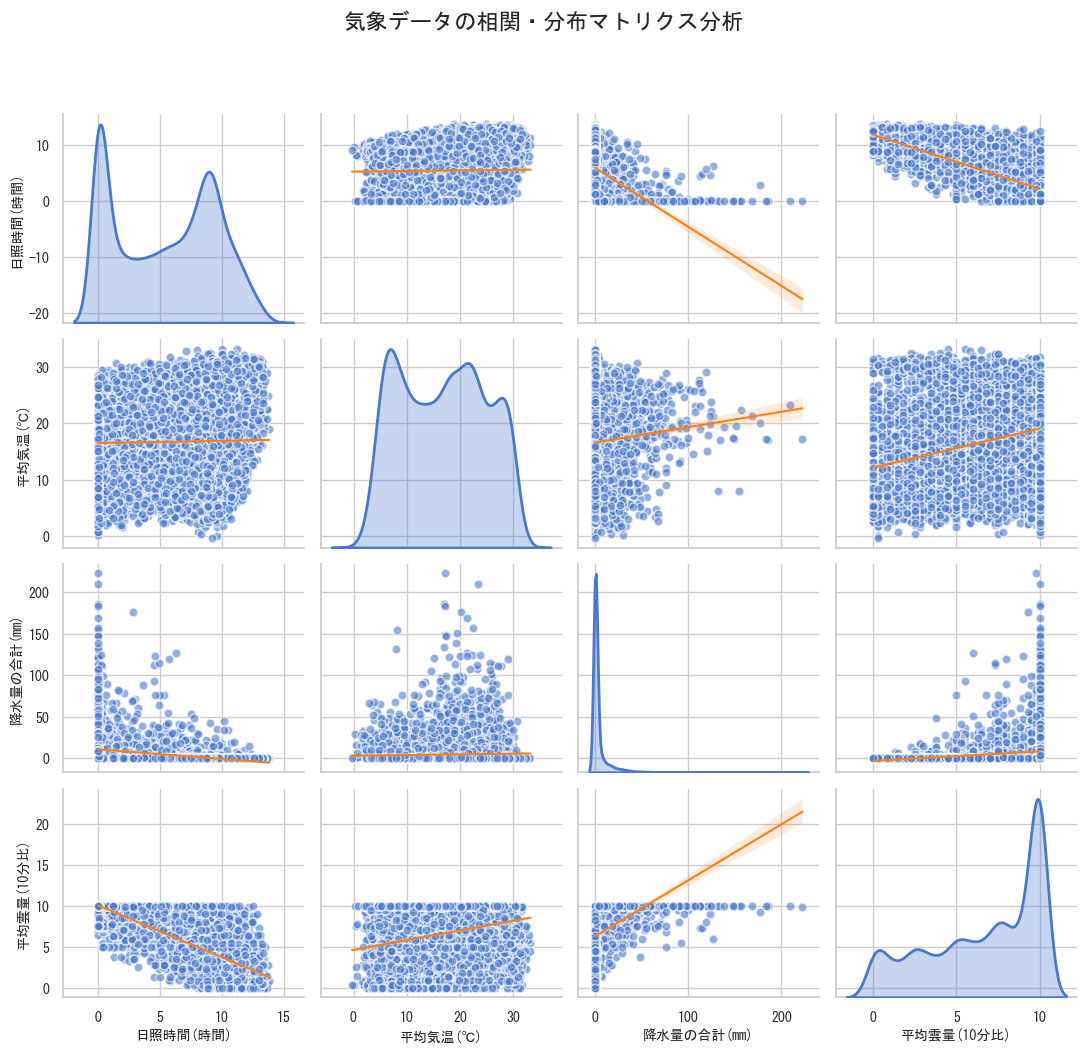

In [ ]:
# seabornとmatplotlibをインポートして、グラフのスタイルを整える
# まずは、pairplotでデータの傾向を確認する
# 色々と綺麗に見える設定を盛り込んで作図
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 1. Windowsのフォントファイルを直接指定して読み込む
font_path = "C:/Windows/Fonts/msgothic.ttc"  # MSゴシック
font_prop = font_manager.FontProperties(fname=font_path)

# 2. Matplotlibのシステム自体にこのフォントを無理やり登録する（★これがVS Codeで効くポイント！）
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止

# 3. グラフ全体の見た目のテーマを設定
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11  # 文字サイズを微調整

# 4. 美しいpairplotの描画
g = sns.pairplot(
    df_mysql, 
    vars=['日照時間(時間)', '平均気温(℃)', '降水量の合計(mm)', '平均雲量(10分比)'],
    kind='reg',            # 回帰直線
    plot_kws={
        'scatter_kws': {'edgecolor': 'white', 'alpha': 0.6, 's': 40},
        'line_kws': {'color': '#ff7f0e', 'linewidth': 1.5}
    },
    diag_kind='kde',       # 密度曲線
    diag_kws={'fill': True, 'shade': True, 'alpha': 0.3, 'linewidth': 2},
    height=2.5,
    aspect=1.1
)

# 5. 【VS Code対策】大量にあるグラフのラベル一つ一つにフォントを強制適用する
for ax in g.axes.flat:
    if ax is not None:
        # 横軸・縦軸の「項目名」を日本語化
        ax.xaxis.label.set_fontproperties(font_prop)
        ax.yaxis.label.set_fontproperties(font_prop)
        # 軸の「数字」部分のフォントも統一
        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontproperties(font_prop)

# タイトルにもフォントを適用
g.fig.suptitle("気象データの相関・分布マトリクス分析", y=1.05, fontproperties=font_prop, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

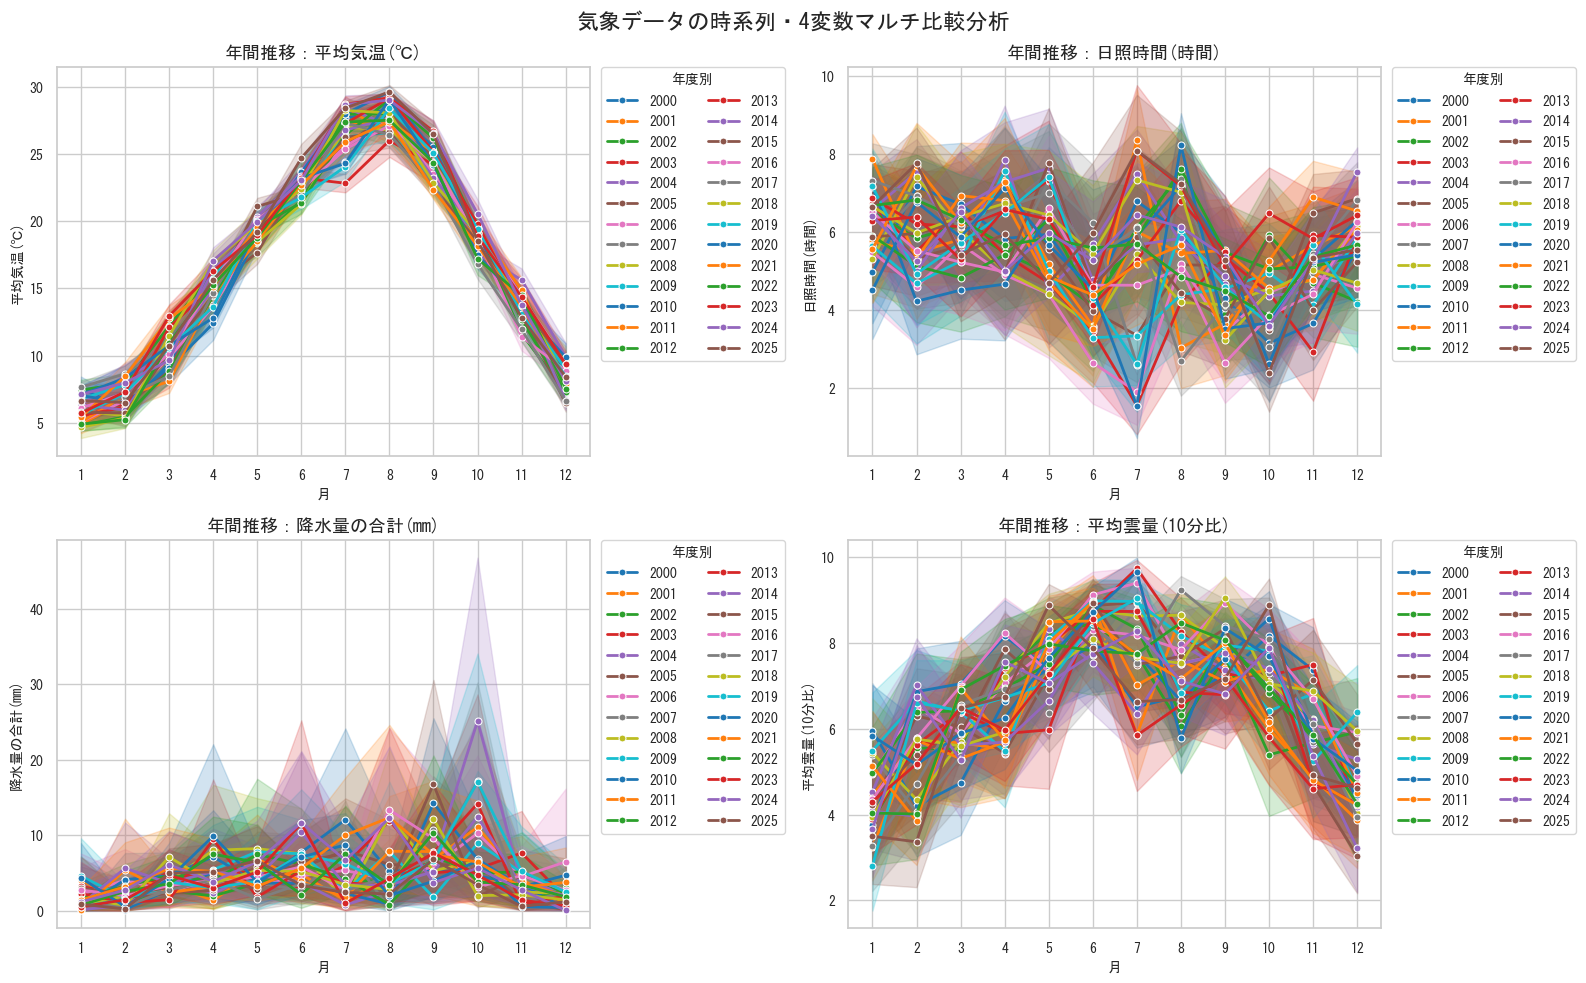

In [ ]:
# --- 3. グラフの描画設定（2行2列の4画面に変更！） ---
# 💡 修正：1行2列から「2行2列 (2, 2)」にして、全体のサイズを大きく(16, 10)しました
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 💡 修正：調べたい4つの項目をすべてリストに入れます
targets = ['平均気温(℃)', '日照時間(時間)', '降水量の合計(mm)', '平均雲量(10分比)']

# 2行2列の画面（axes）を1次元のリスト（4個）に平らにして扱いやすくするおまじない
axes_flat = axes.flatten()

for i, target in enumerate(targets):
    ax = axes_flat[i]  # 💡 0番目〜3番目の画面を順番に使う
    
    # lineplotで各変数をプロット
    sns.lineplot(
        data=df_mysql,
        x='月',
        y=target,
        hue='年',          # 年ごとに色分け
        marker='o',         # 各月に丸いドットを打つ
        markersize=5,       # 4画面なのでドットを少し小さめに
        linewidth=2,        # 線の太さを少し細めに調整
        palette='tab10',    
        ax=ax
    )
    
    # デザインの微調整
    ax.set_title(f'年間推移：{target}', fontproperties=font_prop, fontsize=13, fontweight='bold')
    ax.set_xlabel('月', fontproperties=font_prop)
    ax.set_ylabel(target, fontproperties=font_prop)
    ax.set_xticks(range(1, 13)) 
    
    # 軸の文字のフォント適用
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(font_prop)

    # 💡 凡例の設定（各グラフの右側に綺麗に配置）
    leg = ax.legend(
        loc='upper left',           
        bbox_to_anchor=(1.02, 1.0),  
        ncol=2,                     # 2列に並べる
        borderaxespad=0.,           
        title="年度別"               
    )   
    
    # 凡例のフォント適用
    leg.get_title().set_fontproperties(font_prop)
    for text in leg.get_texts():
        text.set_fontproperties(font_prop)

# 全体のタイトル
fig.suptitle("気象データの時系列・4変数マルチ比較分析", fontproperties=font_prop, fontsize=16, fontweight='bold', y=0.98)

# 4つのグラフと右側の凡例がきれいに収まるように余白を自動調整
plt.tight_layout()
plt.show()

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid

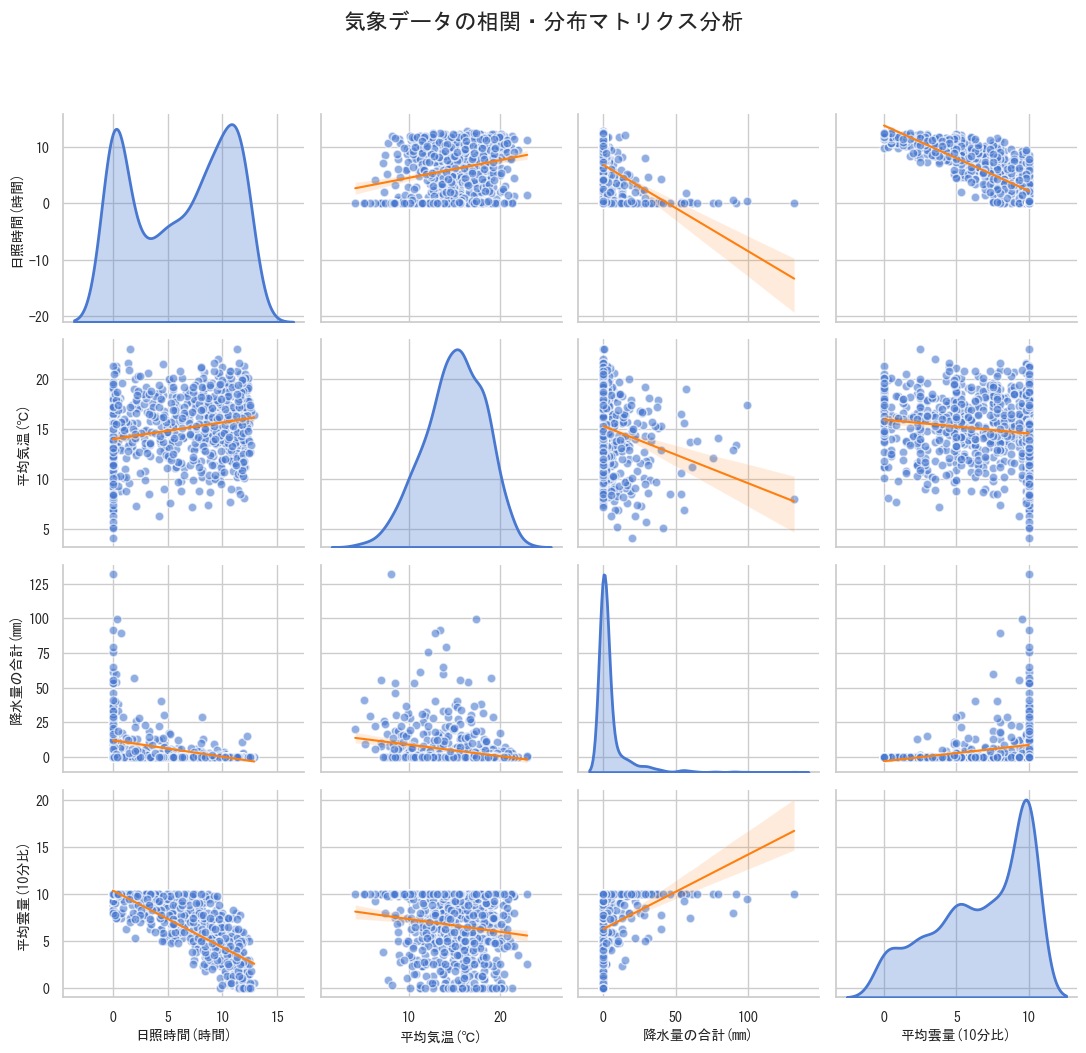

In [ ]:
# 特定の月のデータだけを切り出してペアプロットを描く
df_month = df_mysql[df_mysql['月'] == 4]
# 2. Matplotlibのシステム自体にこのフォントを無理やり登録する（★これがVS Codeで効くポイント！）
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止

# 3. グラフ全体の見た目のテーマを設定
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11  # 文字サイズを微調整

# 4. 美しいpairplotの描画
g = sns.pairplot(
    df_month, 
    vars=['日照時間(時間)', '平均気温(℃)', '降水量の合計(mm)', '平均雲量(10分比)'],
    kind='reg',            # 回帰直線
    plot_kws={
        'scatter_kws': {'edgecolor': 'white', 'alpha': 0.6, 's': 40},
        'line_kws': {'color': '#ff7f0e', 'linewidth': 1.5}
    },
    diag_kind='kde',       # 密度曲線
    diag_kws={'fill': True, 'shade': True, 'alpha': 0.3, 'linewidth': 2},
    height=2.5,
    aspect=1.1
)

# 5. 【VS Code対策】大量にあるグラフのラベル一つ一つにフォントを強制適用する
for ax in g.axes.flat:
    if ax is not None:
        # 横軸・縦軸の「項目名」を日本語化
        ax.xaxis.label.set_fontproperties(font_prop)
        ax.yaxis.label.set_fontproperties(font_prop)
        # 軸の「数字」部分のフォントも統一
        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontproperties(font_prop)

# タイトルにもフォントを適用
g.fig.suptitle("気象データの相関・分布マトリクス分析", y=1.05, fontproperties=font_prop, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 💡 月ごとにグループ分けして、「平均気温」と「日照時間」の相関係数を計算する
monthly_corr = df_mysql.groupby('月')[['平均気温(℃)', '日照時間(時間)']].corr().iloc[0::2,-1].reset_index()

# 見やすく名前を整える
monthly_corr = monthly_corr.rename(columns={'日照時間(時間)': '相関係数'}).drop('level_1', axis=1)

print("📊 【月別】平均気温と日照時間の相関係数一覧")
print(monthly_corr.to_string(index=False))

📊 【月別】平均気温と日照時間の相関係数一覧
 月      相関係数
 1  0.041468
 2  0.106364
 3  0.196077
 4  0.229709
 5  0.374893
 6  0.413578
 7  0.689909
 8  0.710556
 9  0.449613
10  0.211301
11  0.073373
12 -0.054469


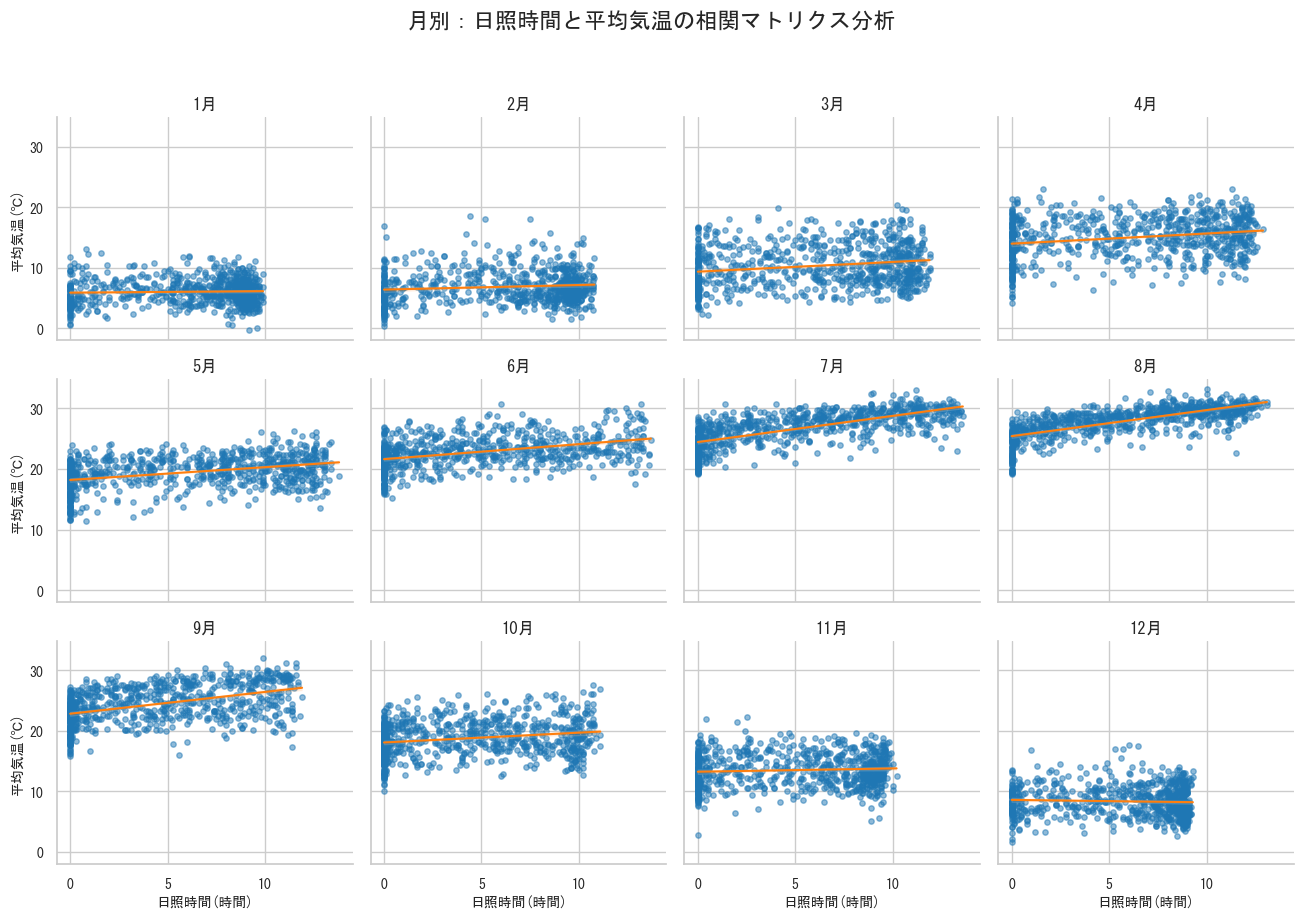

In [ ]:
# グラフのベース設定（VS Code日本語化対策）
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 💡 col='月' で月ごとに部屋を分け、col_wrap=4 で「横に4つ並んだら改行（計3行）」にする設定
g = sns.FacetGrid(
    df_mysql, 
    col="月", 
    col_wrap=4, 
    height=3, 
    aspect=1.1
)

# 💡 それぞれの部屋に「散布図 + 回帰直線（regplot）」を描画する
g.map_dataframe(
    sns.regplot, 
    x="日照時間(時間)", 
    y="平均気温(℃)",
    scatter_kws={'alpha': 0.5, 's': 15, 'color': '#1f77b4'}, # 点の透明度と大きさ
    line_kws={'color': '#ff7f0e', 'linewidth': 1.5}          # 回帰直線の色
)

# 💡 各グラフのタイトルや軸の日本語化（VS Code対策）
g.set_titles(template="{col_name}月", fontproperties=font_prop, size=12, weight='bold')
for ax in g.axes.flat:
    ax.set_xlabel("日照時間(時間)", fontproperties=font_prop, size=10)
    ax.set_ylabel("平均気温(℃)", fontproperties=font_prop, size=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(font_prop)

# 全体のタイトル設定
g.fig.suptitle("月別：日照時間と平均気温の相関マトリクス分析", fontproperties=font_prop, fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
# グラフが凡例やタイトルと被らないようさらに調整
g.fig.subplots_adjust(top=0.9) 
plt.show()

In [ ]:
# --- 1. 独自の「季節」を判定する関数を定義する ---
def get_detailed_season(row):
    # 月と日を取得
    month = row['DateTime'].month
    day = row['DateTime'].day
    
    # 月日を比較しやすいように「4桁の数字（例: 5月25日 -> 525）」にする
    mmdd = month * 100 + day
    
    # 💡 ここで細かい日付のルールを決めます
    if 301 <= mmdd <= 524:
        return '春'
    elif 525 <= mmdd <= 715:  # 5月末（5/25）〜7月中旬（7/15）を梅雨に設定！
        return '梅雨'
    elif 716 <= mmdd <= 831:
        return '夏'
    elif 901 <= mmdd <= 1130:
        return '秋'
    else:                     # 12/1〜2/28（29）
        return '冬'

# --- 2. データに「独自の季節」カラムを追加 ---
# 💡 row（1行ずつ）を関数に渡して判定させます
df_mysql['独自の季節'] = df_mysql.apply(get_detailed_season, axis=1)


# --- 3. 可視化（散布図マトリクス） ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 季節ごとに部屋を分ける（5つの季節なので、横に5つ並べます）
g = sns.FacetGrid(
    df_mysql, 
    col="独自の季節", 
    col_order=['春', '梅雨', '夏', '秋', '冬'], # 見やすいように並び順を指定
    height=3.5, 
    aspect=0.9
)

# 散布図と回帰直線を描画
# 部屋ごとに散布図を描画する部分を「プロ仕様」にアップデート！
g.map_dataframe(
    sns.regplot, 
    x="日照時間(時間)", 
    y="平均気温(℃)",
    
    # 💡 改善①：点（プロット）のデザインを極める
    scatter_kws={
        'alpha': 0.35,          # 絶妙な透明度（データが重なるところが濃くなる）
        's': 25,                # 小さすぎず大きすぎないサイズ
        'color': '#2c3e50',     # 高級感のあるダークネイビー（元データ）
        'edgecolor': 'none'     # 枠線を消してフチを滑らかに
    },
    
    # 💡 改善②：回帰直線のデザインを極める
    line_kws={
        'color': '#e74c3c',     # 補色にあたる鮮やかなトマトレッド（視線を誘導）
        'linewidth': 2.5,       # 直線を少し太くして強調
        'linestyle': '-'        # ソリッドな直線
    },
    
    # 💡 改善③：信頼区間（うっすらした影）をお上品にする
    ci=95,                      # 統計的な信頼区間（95%）を表示
    robust=True                 # 異常値に引っ張られない綺麗な直線を引く魔法のオプション
)

# 💡 改善④：全体の背景デザインを「引き算」でスッキリさせる
sns.despine(left=True, bottom=True)  # 外枠の無駄な黒い線を消し去る
# 日本語化の調整
g.set_titles(template="{col_name}", fontproperties=font_prop, size=14, weight='bold')
for ax in g.axes.flat:
    ax.set_xlabel("日照時間(時間)", fontproperties=font_prop, size=10)
    ax.set_ylabel("平均気温(℃)", fontproperties=font_prop, size=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(font_prop)

g.fig.suptitle("オリジナル季節区分による日照時間と平均気温の相関", fontproperties=font_prop, fontsize=16, fontweight='bold', y=1.05)
plt.show()

NameError: name 'df_mysql' is not defined